### Download kaggle dataset

In [114]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

### Load dataset

In [115]:
import pandas as pd
import os

df = pd.read_csv(os.path.join(path, "creditcard.csv"))

### Prepare datasets

In [120]:
from sklearn.model_selection import train_test_split

df = df.drop(columns=["Amount", "Time"])

normal = df[df["Class"] == 0]
fraud  = df[df["Class"] == 1]

# 80% of normals -> training; 20% held out for evaluation
train, normal_holdout = train_test_split(normal, test_size=0.2, random_state=42)

# holdout normals + all frauds, split 50/50 into CV and test
holdout = pd.concat([normal_holdout, fraud])
cv, test = train_test_split(
    holdout, test_size=0.5, random_state=42, stratify=holdout["Class"]
)

# scale Amount using TRAINING statistics only
# mu_a, sd_a = train["Amount"].mean(), train["Amount"].std()
# for part in (train, cv, test):
#     part["Amount"] = (part["Amount"] - mu_a) / sd_a

# separate features from labels
X_train = train.drop(columns="Class")          # all zeros anyway
X_cv,  y_cv  = cv.drop(columns="Class"),  cv["Class"]
X_test, y_test = test.drop(columns="Class"), test["Class"]

### Density Estimation Algorithm

In [125]:
import numpy as np

# vectorized implementation of f1 score
def calculate_f1_score(y, preds):
    y, preds = np.asarray(y), np.asarray(preds)
    tp = np.sum((preds == 1) & (y == 1))
    if tp == 0:
        return 0.0, 0.0, 0.0
    precision = tp / preds.sum()
    recall = tp / y.sum()
    f1_score = 2 * precision * recall / (precision + recall)
    return f1_score, precision, recall

def fit_model(X_learn):
    feat_mu, feat_sigma = X_learn.mean(axis=0), X_learn.std(axis=0)
    # For avoiding flaot underflow we use calculate the normal distribution using log_e
    def log_density(X):
        f_x = -np.log(feat_sigma * np.sqrt(2 * np.pi)) - (X - feat_mu)**2 / (2 * feat_sigma**2)
        preds = np.sum(f_x, axis=1)
        return preds
    return log_density, feat_mu, feat_sigma

def find_optimal_eps(model, X_val, y_val, iters=1000):
    log_p_val = model(X_val)
    history = {"eps": [], "f1": [], "precision": [], "recall": []}
    for eps in np.linspace(log_p_val.min(), log_p_val.max(), iters):
        preds = (log_p_val < eps).astype(int)
        f1, precision, recall = calculate_f1_score(y_val, preds)
        history["eps"].append(eps)
        history["f1"].append(f1)
        history["precision"].append(precision)
        history["recall"].append(recall)
    best_idx = int(np.argmax(history["f1"]))
    return history["eps"][best_idx], history

def create_anomaly_detection(model, eps):
    def anomaly_detection(X):
        return model(X) < eps
    return anomaly_detection

In [132]:
log_density_model, mu, sigma = fit_model(X_train)

### Test the model against X_test

In [148]:
# final evaluation on the test set
detector = create_anomaly_detection(log_density_model, best_eps)

test_preds = detector(X_test).astype(int)
f1, precision, recall = calculate_f1_score(y_test, test_preds)
tp = np.sum((test_preds == 1) & (y_test == 1))
fp = np.sum((test_preds == 1) & (y_test == 0))
fn = np.sum((test_preds == 0) & (y_test == 1))
tn = np.sum((test_preds == 0) & (y_test == 0))

from sklearn.metrics import f1_score
sklearn_f1_score = f1_score(y_test, test_preds)

print(f"Caught frauds:   {tp} / {tp + fn}")
print(f"False alarms:    {fp}")
print(f"Test set results (eps = {best_eps:.2f})")
print(f"sklearn F1:{sklearn_f1_score:.4f}")
print(f"F1:        {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")

Caught frauds:   145 / 246
False alarms:    213
Test set results (eps = -147.81)
sklearn F1:0.4801
F1:        0.4801
Precision: 0.4050
Recall:    0.5894


## Performance plots

### 1 - Model performance vs eps

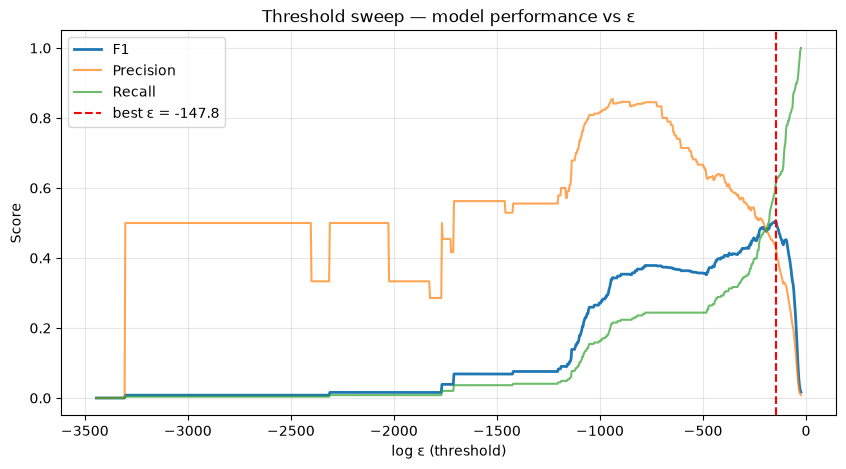

In [133]:
import matplotlib.pyplot as plt

best_eps, h = find_optimal_eps(log_density_model, X_cv, y_cv)

plt.figure(figsize=(10, 5))
plt.plot(h["eps"], h["f1"], label="F1", linewidth=2)
plt.plot(h["eps"], h["precision"], label="Precision", alpha=0.7)
plt.plot(h["eps"], h["recall"], label="Recall", alpha=0.7)
plt.axvline(best_eps, color="red", linestyle="--", label=f"best ε = {best_eps:.1f}")
plt.xlabel("log ε (threshold)")
plt.ylabel("Score")
plt.title("Threshold sweep — model performance vs ε")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 2 - Precision vs recall curve

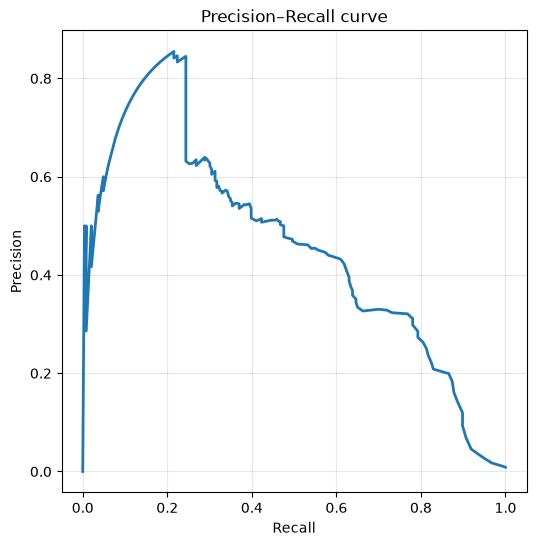

In [134]:
plt.figure(figsize=(6, 6))
plt.plot(h["recall"], h["precision"], linewidth=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall curve")
plt.grid(alpha=0.3)
plt.show()